![IITIS](pictures/logoIITISduze.png)

# Algorytm symulowanego wyżarzania

Symulowane wyżarzanie (*simulated annealing*) to probabilistyczna technika optymalizacyjna inspirowana procesem wyżarzania w metalurgii. Naśladuje fizyczny proces podgrzewania i powolnego schładzania materiału w celu usunięcia defektów. W kontekście optymalizacji „temperatura” jest skalarnym parametrem algorytmu. 

## Ogólny zarys
Rozpoczyna się od początkowego rozwiązania i wysokiej temperatury, która jest stopniowo obniżana. Na każdym etapie SA losowo modyfikuje bieżące rozwiązanie w celu wygenerowania nowego kandydata. Jeśli nowe rozwiązanie jest lepsze, zostaje zaakceptowane. Jeśli jest gorsze, może również zostać zaakceptowane z pewnym prawdopodobieństwem, które jest proporcjonalne do temperatury. Pozwala to algorytmowi uniknąć lokalnych ekstremów i z czasem przybliżyć rozwiązanie optymalne w skali globalnej.


Podstawowa wersja algorytmu:

1. Inicjalizacja: $s = s_0$, $T = T_{innit}$
2. For $k \in [0, \ldots, k_{max} - 1]$
    * Wybór sąsiada $s' = \text{neighbour}(s)$
    * $\beta$ = 1/T
    * Policzenie $\Delta E = E(s') - E(s)$, $P(\Delta E, \beta)$
    * Jeżeli $P(\Delta E, \beta)$ > random$(0,1)$
        * s = s'
    * $T = T_{innit} * \frac{k + 1}{k_{max}}$
3. Zwróć $s$, $E(s)$

In [64]:
import random
import numpy as np
from copy import deepcopy
from math import exp


# Na początek zdefiniujemy potrzebne funkcje pomocnicze
def calculate_energy(J: np.ndarray, h: np.ndarray, conf: np.ndarray):
    return conf @ J @ conf.T + conf @ h 

def neightbour(conf: np.ndarray):
    flip_idx = random.randint(0, len(conf) - 1)
    new_conf = deepcopy(conf) 
    new_conf[flip_idx] *= -1  # zmieniamy spin losowego wierzchołka
    return new_conf

def acceptance_probability(delta_e: float, temp: float):
    if delta_e < 0:
        return 1
    else:
        beta = 1/temp
        probability = exp(-beta * delta_e)
        
        return probability


# definicja algorytmu
def simulated_annealing(J, h, initial_temp: float, num_steps: int):
    """
    Spróbuj zaimplementować symulowane wyżarzanie zgodnie z pseudokodem podanym wyżej
    """
    ...
        
 


In [ ]:
# przykładowe rozwiązanie
def simulated_annealing(J, h, initial_temp: float, num_steps: int):
    temp = initial_temp
    solution = np.array([random.choice([-1, 1]) for _ in range(len(h))])
    energy = calculate_energy(J, h, solution)

    for k in range(num_steps):
        new_solution = neightbour(solution)
        new_energy = calculate_energy(J, h, new_solution)
        delta_e = new_energy - energy

        r = random.random()
        
        if acceptance_probability(delta_e, temp) > r:
            solution = new_solution
            energy = new_energy


        temp = initial_temp * (1 - ((k + 1)/num_steps ))

    return solution, energy

In [65]:
# wygenerujmy losową gęstą instancję
n = 20

scaling_func = np.vectorize(lambda x: 2*x-1)  # przesunięcie wartości z (0, 1) do (-1, 1)
J = np.triu(scaling_func(np.random.rand(n, n)))  # losowa gęsta macierz górnotrójkątna
h = scaling_func(np.random.rand(n))  # losowy wektor

init_conf = np.array([random.choice([-1, 1]) for _ in range(n)])




In [79]:
# Przetestujmy nasz algorytm
# Parametry którymi możemy teraz operować to początkowa temperatura i ilość kroków
init_temp = 100
num_steps = 100000
state, energy = simulated_annealing(J, h, init_temp, num_steps)

print(state)
print(energy)

[ 1  1 -1  1 -1 -1  1 -1  1 -1  1  1 -1 -1  1  1  1 -1 -1  1]
-42.72016683235893


In [80]:
# Porównanie ze zoptymalizowanym komercyjnym algorytmem

from dimod import BinaryQuadraticModel
from dwave.samplers import SimulatedAnnealingSampler

bqm_instance = BinaryQuadraticModel(h, J, vartype="SPIN")
sampler= SimulatedAnnealingSampler()
sampleset = sampler.sample(bqm_instance, num_reads=1)
print(sampleset)



   0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 ... 19     energy num_oc.
0 +1 +1 -1 +1 -1 -1 +1 -1 +1 -1 +1 +1 -1 -1 +1 +1 +1 ... +1 -42.720167       1
['SPIN', 1 rows, 1 samples, 20 variables]


## Rozszerzenia
Generalnie w literaturze można spokać kilka sposobób modyfikacji tego algorytmu. Można to zrobić ingerująć w:
1. Jak się zmienia temperatura, czyli tzw. harmonogram wyżarzania (ang. *annealing schelude*)
2. Wyznaczanie sąsiadów (funkcja `neighbour`)
3. Prawdopodobieństwo akceptacjii.
4. Restart i ponowne wyżarzanie

Zajmiemy się teraz tymi rodzajami po kolei.


### Temperatura
Poniżej są przedstawione wybrane popularne harmonogramy wyżarzania, które można spotkać w komercyjnych implementacjach tego algorytmu

* Liniowy
* Wykładniczy
* Geometryczny
* Szybki


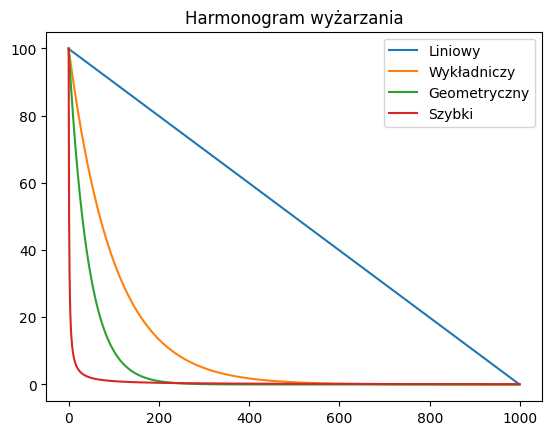

In [89]:
# Narysowane na wykresie

import matplotlib.pyplot as plt

num_steps = 1000
innit_temp = 100
x = list(range(num_steps))

def linear_schedule(innit_temp, num_steps):
    return [innit_temp * (1 - (k + 1)/num_steps) for k in range(num_steps)]

def exponenetial_schedule(innit_temp, num_steps, cooling_step):
    return [innit_temp * cooling_step ** k for k in range(num_steps)]

def geometric_schedule(innit_temp, num_steps, geometric_endpoint):
    return np.geomspace(innit_temp, geometric_endpoint, num=num_steps)

def fast_schedule(innit_temp, num_steps):
    return [innit_temp/(k+1) for k in range(num_steps)]

plt.plot(x, linear_schedule(innit_temp, num_steps))
plt.plot(x, exponenetial_schedule(innit_temp, num_steps, 0.99))
plt.plot(x, geometric_schedule(innit_temp, num_steps, 1e-8))
plt.plot(x, fast_schedule(innit_temp, num_steps))
plt.title("Harmonogram wyżarzania")
plt.legend(["Liniowy", "Wykładniczy", "Geometryczny", "Szybki"])

plt.show()